In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline
import pygmsh 

In [35]:
#Estracción de datos físicos
datos = pd.read_csv('properties_dataNonDim.csv')
theta = datos['T_params']
alpha = datos[' C_nondim_curve']
kappa = datos[' K_nondim_curve']

<function matplotlib.pyplot.show(close=None, block=None)>

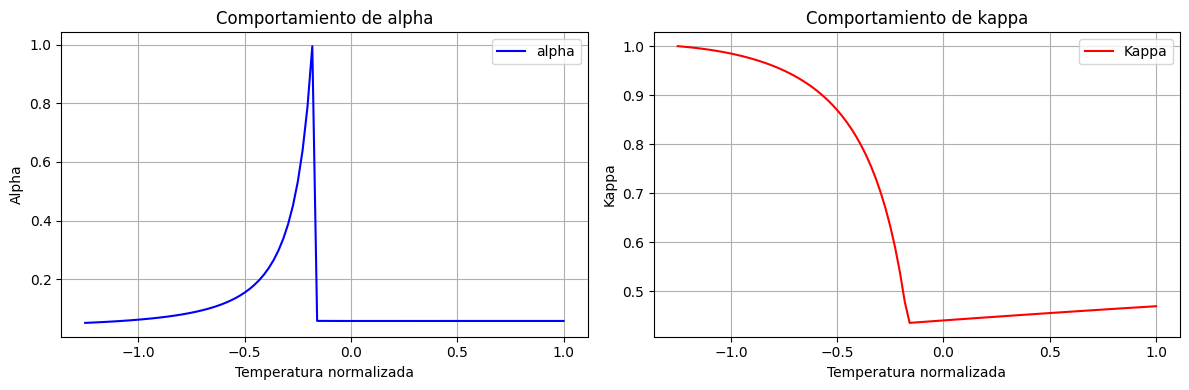

In [36]:
#Graficas de los parámetros físicos
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12, 4))

ax1.plot(theta, alpha, color = 'blue', label = 'alpha')
ax1.set_title('Comportamiento de alpha')
ax1.set_xlabel('Temperatura normalizada')
ax1.set_ylabel('Alpha')
ax1.grid(True)
ax1.legend()

ax2.plot(theta, kappa, color = 'red', label = 'Kappa')
ax2.set_title('Comportamiento de kappa')
ax2.set_xlabel('Temperatura normalizada')
ax2.set_ylabel('Kappa')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show

In [37]:
#Interpoladores
f_alpha = CubicSpline(theta, alpha)
f_kappa = CubicSpline(theta, kappa)
df_alpha = f_alpha.derivative()
df_kappa = f_kappa.derivative()

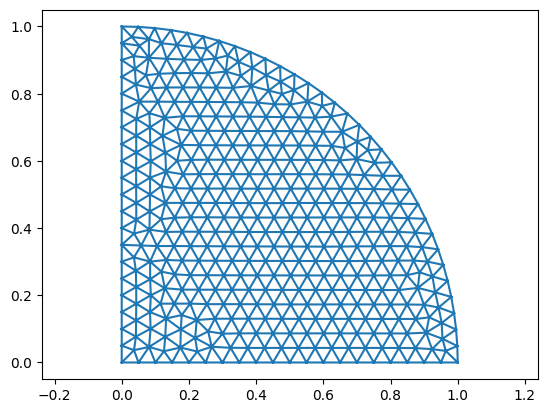

In [38]:
#Generación de mallas, lc controla el refinamiento
lc = 0.05
with pygmsh.geo.Geometry() as geom:
    p0 = geom.add_point([0.0, 0.0, 0.0], mesh_size = lc)
    p1 = geom.add_point([1.0, 0.0, 0.0], mesh_size = lc)
    p2 = geom.add_point([0.0, 1.0, 0.0], mesh_size = lc)
    l1 = geom.add_line(p0, p1)
    l2 = geom.add_circle_arc(p1, p0, p2)
    geom.add_physical(l2, label='frontera')
    l3 = geom.add_line(p2, p0)
    contorno = geom.add_curve_loop([l1, l2, l3])
    superficie = geom.add_plane_surface(contorno)
    malla = geom.generate_mesh()
    pass
nodos = malla.points[:, 0:2]
elementos = malla.cells_dict['triangle']
x_coor = nodos[:, 0]
y_coor = nodos[:, 1]
plt.triplot(x_coor, y_coor, elementos)
plt.axis('equal')
plt.show()



In [39]:
#Generar las matrices locales

def calcular_matrices_locales(v0, v1,v2 , theta_n_elem, theta_k_elem, delta_tau):
    x0, y0 = v0[0], v0[1]
    x1, y1 = v1[0], v1[1]
    x2, y2 = v2[0], v2[1]

    J_geo = np.array([[x1 - x0, x2 - x0],
                  [y1 - y0, y2 - y0]],
                )
    
    invJ = np.linalg.inv(J_geo)
    detJ = np.abs((x1 - x0) * (y2 - y0) - (x2 - x0) * (y1 - y0))

    D = np.array([[-1, 1, 0],
                  [-1, 0, 1]])
    
    theta_n_mean = np.mean(theta_n_elem)
    theta_k_mean = np.mean(theta_k_elem)

    M_local = (df_alpha(theta_k_mean)* theta_k_mean + f_alpha(theta_k_mean)) * (detJ / 24) * np.array([[2,1,1],[1,2,1],[1,1,2]])

    K_local_1 = f_kappa(theta_k_mean)* (detJ / 2) * (invJ @ D).T @ (invJ @ D)
    K_local_2 = df_kappa(theta_k_mean) * (detJ / 6) * ( ((invJ @ D).T @ (invJ @ D) @ theta_k_elem).reshape(3, 1) @ np.array([[1, 1, 1]]) )

    J_local = M_local + delta_tau * (K_local_1 + K_local_2)
    r_local = f_alpha(theta_n_mean) * theta_n_mean * (detJ / 6) * np.array([1, 1, 1])  - f_alpha(theta_k_mean) * theta_k_mean * (detJ / 6) * np.array([1, 1, 1]) - delta_tau * f_kappa(theta_k_mean) * (detJ / 2) * ((invJ @ D).T @ (invJ @ D) @ theta_k_elem)
    

    return J_local, r_local

In [40]:
#Ensamblaje de matrices globales


def ensablaje_matrices_globales(nodos, elementos, theta_n, theta_k, delta_tau): 
    num_nodos = len(nodos)
    J_global = np.zeros((num_nodos, num_nodos))
    r_global = np.zeros(num_nodos)

    for elemento in elementos:
        v0 = nodos[elemento[0]]
        v1 = nodos[elemento[1]]
        v2 = nodos[elemento[2]]
        
        theta_k_elem = np.array(theta_k[elemento])
        theta_n_elem = np.array(theta_n[elemento])

        J_local, r_local = calcular_matrices_locales(v0, v1, v2, theta_n_elem, theta_k_elem, delta_tau)


        for i in range(3):
            r_global[elemento[i]] += r_local[i]
            for j in range(3):
                J_global[elemento[i], elemento[j]] += J_local[i, j]
               
                
    return J_global, r_global 


In [41]:
#Extracción de nodos en la frontera
indices_lineas = malla.cell_sets_dict['frontera']['line']
lineas_curvas = malla.cells_dict['line'][indices_lineas]
nodos_frontera = np.unique(lineas_curvas)

w_n = 2.25 * np.ones(len(nodos)) #Variable de temperatura auxiliar inicial
for n in nodos_frontera:
    w_n[n] = 0

nodos_todos = np.arange(len(nodos))
nodos_interiores = np.setdiff1d(nodos_todos, nodos_frontera)

In [42]:
#Solución del sistema:
pasos_tiempo = 20
delta_tau = 0.001
max_iteraciones = 100

for paso in range(pasos_tiempo):
    theta_k = np.copy(w_n)

    for iteracion in range(max_iteraciones):
        J_global, r_global = ensablaje_matrices_globales(nodos, elementos, w_n, theta_k, delta_tau)
        J_int = J_global[np.ix_(nodos_interiores, nodos_interiores)]
        r_int = r_global[nodos_interiores]
        w_int = w_n[nodos_interiores]

        delta_w_int = np.linalg.solve(J_int, r_int)
        theta_k[nodos_interiores] += delta_w_int
        if np.linalg.norm(delta_w_int) <= 1e-6:
            break
    
    w_n = np.copy(theta_k)

    if paso % 1000 == 0: print(f"Paso {paso}")

theta_final = w_n - 1.25           
            




Paso 0


In [43]:
theta_final

array([-1.25      , -1.25      , -1.25      , -1.25      , -1.25      ,
       -1.25      , -1.25      , -1.25      , -1.25      , -1.25      ,
       -1.25      , -1.25      , -1.25      , -1.25      , -1.25      ,
       -1.25      , -1.25      , -1.25      , -1.25      , -1.25      ,
       -1.25      , -1.25      , -1.25      , -1.25      , -1.25      ,
       -1.25      , -1.25      , -1.25      , -1.25      , -1.25      ,
       -1.25      , -1.25      , -1.25      , -0.14503244, -0.14893499,
       -0.15292656, -0.17193742, -0.18135478, -0.22440023, -0.24162736,
       -0.31040908, -0.36628007, -0.40056739, -0.49576172, -0.54525923,
       -0.65139486, -0.70502667, -0.81304947, -0.89328699, -0.93700732,
       -1.05145336, -1.10596923, -1.17494698, -1.17481384, -1.09796247,
       -1.01633902, -0.93728664, -0.84009529, -0.76057386, -0.67191624,
       -0.58886908, -0.52438507, -0.45983391, -0.40664406, -0.34201792,
       -0.29129743, -0.25748851, -0.22261116, -0.19729031, -0.17

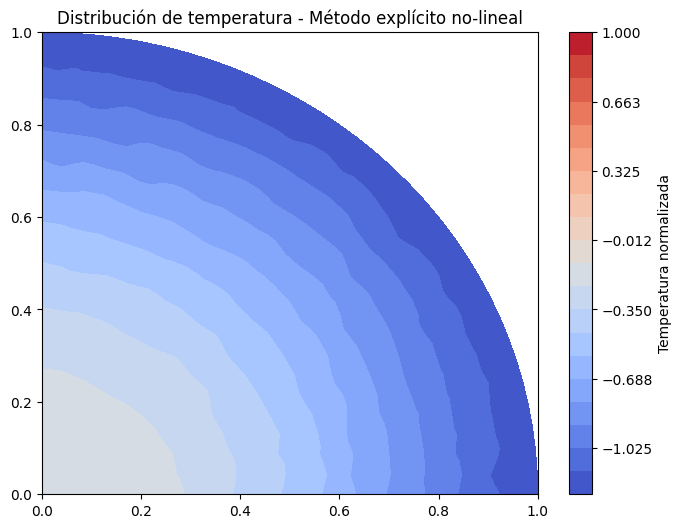

In [44]:
#Grafica de la solución:

limite_inferior = -1.25  
limite_superior = 1.0   
niveles_fijos = np.linspace(limite_inferior, limite_superior, 21)

plt.figure(figsize=(8,6))
plt.title('Distribución de temperatura - Método explícito no-lineal')
grafico = plt.tricontourf(x_coor, y_coor, elementos, theta_final, levels=niveles_fijos, cmap='coolwarm') 
plt.colorbar(grafico, label='Temperatura normalizada')
plt.show()